## **Mount Google Drive**

In [17]:
!rm -rf /content/data

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Define Zip Path and Unzip**

In [20]:
ZIP_PATH = "/content/drive/MyDrive/PlantVillage_Project/data/raw/color.zip"
!mkdir -p /content/data/raw

!unzip -q "{ZIP_PATH}" -d /content/data/raw

print("Unzipped folder contents")
!ls /content/data/raw/color

Unzipped folder contents
 Apple___Apple_scab
 Apple___Black_rot
 Apple___Cedar_apple_rust
 Apple___healthy
 Blueberry___healthy
'Cherry_(including_sour)___healthy'
'Cherry_(including_sour)___Powdery_mildew'
'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
'Corn_(maize)___Common_rust_'
'Corn_(maize)___healthy'
'Corn_(maize)___Northern_Leaf_Blight'
 Grape___Black_rot
'Grape___Esca_(Black_Measles)'
 Grape___healthy
'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'
'Orange___Haunglongbing_(Citrus_greening)'
 Peach___Bacterial_spot
 Peach___healthy
 Pepper,_bell___Bacterial_spot
 Pepper,_bell___healthy
 Potato___Early_blight
 Potato___healthy
 Potato___Late_blight
 Raspberry___healthy
 Soybean___healthy
 Squash___Powdery_mildew
 Strawberry___healthy
 Strawberry___Leaf_scorch
 Tomato___Bacterial_spot
 Tomato___Early_blight
 Tomato___healthy
 Tomato___Late_blight
 Tomato___Leaf_Mold
 Tomato___Septoria_leaf_spot
'Tomato___Spider_mites Two-spotted_spider_mite'
 Tomato___Target_Spot
 Tomato___Tom

In [21]:
print("Total number of classes:")
!ls /content/data/raw/color | wc -l

print("\nFull list of classes:")
!ls /content/data/raw/color

Total number of classes:
38

Full list of classes:
 Apple___Apple_scab
 Apple___Black_rot
 Apple___Cedar_apple_rust
 Apple___healthy
 Blueberry___healthy
'Cherry_(including_sour)___healthy'
'Cherry_(including_sour)___Powdery_mildew'
'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
'Corn_(maize)___Common_rust_'
'Corn_(maize)___healthy'
'Corn_(maize)___Northern_Leaf_Blight'
 Grape___Black_rot
'Grape___Esca_(Black_Measles)'
 Grape___healthy
'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'
'Orange___Haunglongbing_(Citrus_greening)'
 Peach___Bacterial_spot
 Peach___healthy
 Pepper,_bell___Bacterial_spot
 Pepper,_bell___healthy
 Potato___Early_blight
 Potato___healthy
 Potato___Late_blight
 Raspberry___healthy
 Soybean___healthy
 Squash___Powdery_mildew
 Strawberry___healthy
 Strawberry___Leaf_scorch
 Tomato___Bacterial_spot
 Tomato___Early_blight
 Tomato___healthy
 Tomato___Late_blight
 Tomato___Leaf_Mold
 Tomato___Septoria_leaf_spot
'Tomato___Spider_mites Two-spotted_spider_mite'
 Tomato__

## **Set Data Directory & Test**

In [22]:
DATA_DIR = "/content/data/raw/color"
print("DATA directory ready:", DATA_DIR)
print("First 10 classes folders:")
!ls "{DATA_DIR}" | head -n 10

DATA directory ready: /content/data/raw/color
First 10 classes folders:
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy


## **Loading/Splitting The Dataset**

In [23]:
import tensorflow as tf  # ⭐ ADD THIS LINE!
import os

def load_and_prepare_data(data_dir, img_size=224, batch_size=32):
    """Load data and return both datasets and class names."""

    # Load raw datasets
    train_raw = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(img_size, img_size),
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=True
    )

    val_raw = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(img_size, img_size),
        batch_size=batch_size,
        label_mode='categorical',
    )

    # Save class names
    class_names = train_raw.class_names

    # Optimize
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_raw.cache().prefetch(AUTOTUNE)
    val_ds = val_raw.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, class_names

# Usage
DATA_DIR = "/content/data/raw/color"  # Make sure this is defined
train_ds, val_ds, class_names = load_and_prepare_data(DATA_DIR)

print(f"Data loaded successfully!")
print(f"Class names (first 5): {class_names[:5]}")
print(f"Total classes: {len(class_names)}")
print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Data loaded successfully!
Class names (first 5): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Total classes: 38
Training batches: 1358
Validation batches: 340


In [24]:
import os

# Just list what's in your project structure
print("Checking project structure...")
print(f"/content/drive/MyDrive/PlantVillage_Project exists: {os.path.exists('/content/drive/MyDrive/PlantVillage_Project')}")
print(f"/content/drive/MyDrive/PlantVillage_Project/code exists: {os.path.exists('/content/drive/MyDrive/PlantVillage_Project/code')}")
print(f"/content/drive/MyDrive/PlantVillage_Project/code/modules exists: {os.path.exists('/content/drive/MyDrive/PlantVillage_Project/code/modules')}")

# List all files in the modules folder
modules_dir = '/content/drive/MyDrive/PlantVillage_Project/code/modules'
if os.path.exists(modules_dir):
    print(f"\nFiles in modules directory:")
    for file in os.listdir(modules_dir):
        print(f"  - {file}")

Checking project structure...
/content/drive/MyDrive/PlantVillage_Project exists: True
/content/drive/MyDrive/PlantVillage_Project/code exists: True
/content/drive/MyDrive/PlantVillage_Project/code/modules exists: True

Files in modules directory:
  - __init__.py
  - __pycache__
  - pipelines.py
  - preprocessing.py
  - tf_datapipeline.py


In [25]:
import sys
import os

# Add project module directory to Python path
project_path = "/content/drive/MyDrive/PlantVillage_Project"
modules_path = os.path.join(project_path, "code/modules")
sys.path.append(modules_path)

print(f"Project path: {project_path}")
print(f"Modules path: {modules_path}")

# Check if the modules directory exists
if os.path.exists(modules_path):
    print(f"Success: Modules directory exists")
    print(f"Files in modules directory: {os.listdir(modules_path)}")
else:
    print(f"Error: Modules directory does not exist at {modules_path}")

# Now, let's check for the specific files in the correct locations
required_files = [
    ('pipelines.py', modules_path),
    ('preprocessing.py', modules_path),
    ('tf_datapipeline.py', modules_path),
    ('.env', os.path.join(project_path, "code"))
]

for file_name, search_path in required_files:
    file_path = os.path.join(search_path, file_name)

    if os.path.exists(file_path):
        print(f"Success: {file_name} exists at: {file_path}")
        # Show first few lines (for .py files)
        if file_name.endswith('.py'):
            try:
                with open(file_path, 'r') as f:
                    first_line = f.readline().strip()
                    print(f"  Preview: {first_line}")
            except Exception as e:
                print(f"  Could not read: {e}")
    else:
        print(f"Error: {file_name} missing at: {file_path}")

# Try to import the modules
print("\n" + "="*50)
print("Attempting to import modules...")

try:
    from pipelines import *
    print("Successfully imported pipelines")
except ImportError as e:
    print(f"Error importing pipelines: {e}")

try:
    from preprocessing import *
    print("Successfully imported preprocessing")
except ImportError as e:
    print(f"Error importing preprocessing: {e}")

try:
    import tf_datapipeline
    print(" Successfully imported tf_datapipeline")
except ImportError as e:
    print(f"Error importing tf_datapipeline: {e}")


Project path: /content/drive/MyDrive/PlantVillage_Project
Modules path: /content/drive/MyDrive/PlantVillage_Project/code/modules
Success: Modules directory exists
Files in modules directory: ['__init__.py', '__pycache__', 'pipelines.py', 'preprocessing.py', 'tf_datapipeline.py']
Success: pipelines.py exists at: /content/drive/MyDrive/PlantVillage_Project/code/modules/pipelines.py
  Preview: import os
Success: preprocessing.py exists at: /content/drive/MyDrive/PlantVillage_Project/code/modules/preprocessing.py
  Preview: import os
Success: tf_datapipeline.py exists at: /content/drive/MyDrive/PlantVillage_Project/code/modules/tf_datapipeline.py
  Preview: import os
Error: .env missing at: /content/drive/MyDrive/PlantVillage_Project/code/.env

Attempting to import modules...
Successfully imported pipelines
Successfully imported preprocessing
 Successfully imported tf_datapipeline


STEP 6: Testing preprocessing pipeline...
Success: Data directory exists at: /content/data/raw/color
Total classes found: 38
First 5 classes: ['Peach___Bacterial_spot', 'Orange___Haunglongbing_(Citrus_greening)', 'Potato___Late_blight', 'Tomato___Target_Spot', 'Blueberry___healthy']

Testing with image: 0978ea5b-dfda-49ee-85fa-a338a9521d8e___Rut._Bact.S 1082.JPG
Path: /content/data/raw/color/Peach___Bacterial_spot/0978ea5b-dfda-49ee-85fa-a338a9521d8e___Rut._Bact.S 1082.JPG
Class: Peach___Bacterial_spot
Success: Image loaded successfully
  Original shape: (256, 256, 3)
  Original dtype: uint8

1. Testing preprocessing (CLAHE only)...
  Success: Preprocessing successful
    Processed shape: (224, 224, 3)
    Min pixel value: 0.0000
    Max pixel value: 255.0000
    Mean pixel value: 123.8542

2. Testing augmentation pipeline...
  Success: Augmentation pipelines created
    Light augmentation: 3 transforms
    Medium augmentation: 6 transforms
    Heavy augmentation: 9 transforms
  Succes

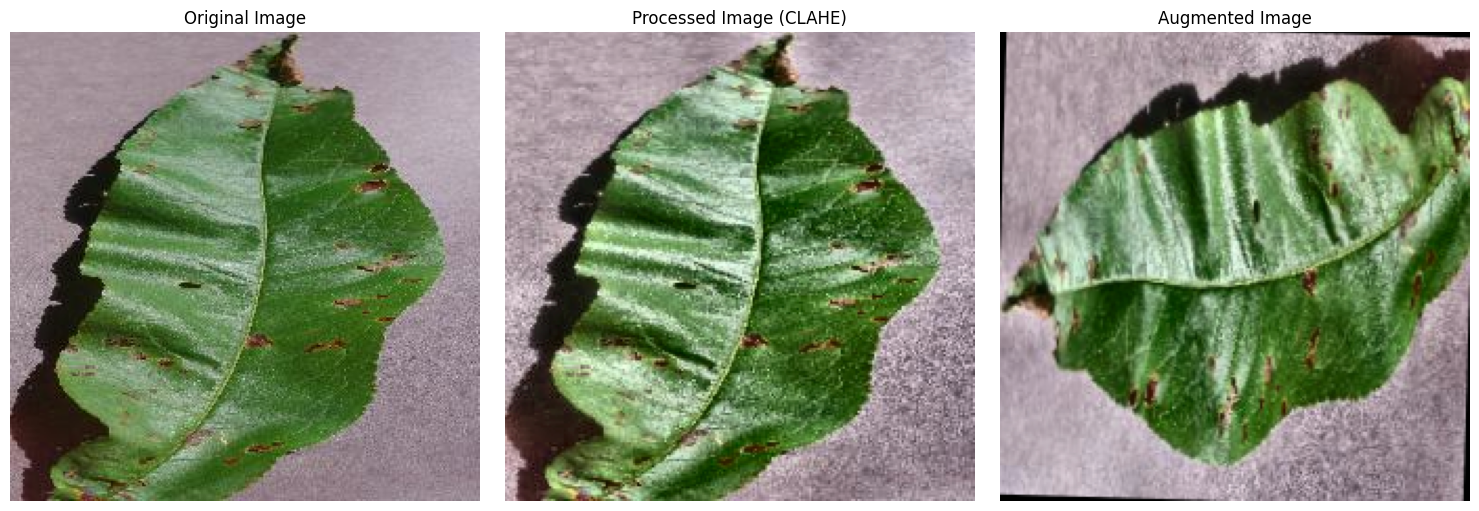

In [26]:
# ============================
# STEP 6: Test with actual image (FIXED VISUALIZATION)
# ============================
print("STEP 6: Testing preprocessing pipeline...")

# Define the data directory in Colab
data_dir = "/content/data/raw/color"

# Check if data exists, if not, unzip from Google Drive
if not os.path.exists(data_dir):
    print(f"Data directory not found. Checking if zip exists...")
    zip_path = "/content/drive/MyDrive/PlantVillage_Project/data/raw/color.zip"

    if os.path.exists(zip_path):
        print(f"Success: Zip file found. Unzipping...")
        !mkdir -p /content/data/raw
        !unzip -q "{zip_path}" -d /content/data/raw
        print(f"Success: Unzipped successfully!")
    else:
        print(f"Error: Zip file not found at: {zip_path}")
        print("Please upload the dataset to Google Drive or Colab.")

# Check if data directory exists
if os.path.exists(data_dir):
    print(f"Success: Data directory exists at: {data_dir}")

    # Get list of classes (plant categories)
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"Total classes found: {len(classes)}")
    print(f"First 5 classes: {classes[:5]}")

    # Find first image in the first class
    first_class = classes[0]
    class_path = os.path.join(data_dir, first_class)

    # List image files in the class folder
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.JPG', '.JPEG', '.PNG']:
        image_files.extend([f for f in os.listdir(class_path) if f.lower().endswith(ext)])

    if image_files:
        first_image = image_files[0]
        image_path = os.path.join(class_path, first_image)
        print(f"\nTesting with image: {first_image}")
        print(f"Path: {image_path}")
        print(f"Class: {first_class}")

        # Load the image
        img = cv2.imread(image_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            print(f"Success: Image loaded successfully")
            print(f"  Original shape: {img.shape}")
            print(f"  Original dtype: {img.dtype}")

            # Test 1: Preprocessing without augmentation
            print("\n1. Testing preprocessing (CLAHE only)...")
            try:
                processed_img = preprocess_numpy_image(img)
                print(f"  Success: Preprocessing successful")
                print(f"    Processed shape: {processed_img.shape}")
                print(f"    Min pixel value: {np.min(processed_img.numpy()):.4f}")
                print(f"    Max pixel value: {np.max(processed_img.numpy()):.4f}")
                print(f"    Mean pixel value: {np.mean(processed_img.numpy()):.4f}")
            except Exception as e:
                print(f"  Error: Preprocessing failed: {e}")

            # Test 2: Augmentation only
            print("\n2. Testing augmentation pipeline...")
            try:
                # Create different augmentation pipelines
                light_aug = get_augmentation_pipeline('light')
                medium_aug = get_augmentation_pipeline('medium')
                heavy_aug = get_augmentation_pipeline('heavy')

                print(f"  Success: Augmentation pipelines created")
                print(f"    Light augmentation: {len(light_aug)} transforms")
                print(f"    Medium augmentation: {len(medium_aug)} transforms")
                print(f"    Heavy augmentation: {len(heavy_aug)} transforms")

                # Test medium augmentation on preprocessed image
                if 'processed_img' in locals():
                    # Convert to numpy
                    test_img = processed_img.numpy()

                    # Albumentations expects uint8 [0,255]
                    if test_img.max() <= 1.0:
                        test_img = (test_img * 255).astype(np.uint8)
                    else:
                        test_img = np.clip(test_img, 0, 255).astype(np.uint8)

                    # Apply augmentation
                    augmented = medium_aug(image=test_img)
                    augmented_img = augmented['image']  # This will be uint8 [0,255]

                    print(f"  Success: Augmentation applied successfully")
                    print(f"    Augmented shape: {augmented_img.shape}")
                    print(f"    Augmented dtype: {augmented_img.dtype}")
            except Exception as e:
                print(f"  Error: Augmentation test failed: {e}")
                import traceback
                traceback.print_exc()

            # Test 3: Combined pipeline (preprocessing + augmentation)
            print("\n3. Testing combined pipeline (CLAHE + Augmentation)...")
            try:
                # Use the create_augmented_preprocessing function
                # Convert image to tensor
                img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)

                # Test with augmentation (training mode)
                processed_augmented, label = create_augmented_preprocessing(
                    img_tensor,
                    tf.constant(0),  # dummy label
                    is_training=True,
                    aug_type='medium'
                )

                print(f"  Success: Combined pipeline successful")
                print(f"    Output shape: {processed_augmented.shape}")
                print(f"    Output dtype: {processed_augmented.dtype}")
                print(f"    Output range: [{tf.reduce_min(processed_augmented):.4f}, {tf.reduce_max(processed_augmented):.4f}]")

            except Exception as e:
                print(f"  Error: Combined pipeline failed: {e}")
                import traceback
                traceback.print_exc()

            # ===== FIXED VISUALIZATION SECTION =====
            print("\n4. Visualizing results (with proper normalization)...")
            import matplotlib.pyplot as plt

            # Prepare images for display (all in [0,1] range for matplotlib)

            # Original image: uint8 [0,255] -> float32 [0,1]
            original_display = img.astype(np.float32) / 255.0

            # Processed image: from preprocess_numpy_image which returns [0,255]
            processed_array = processed_img.numpy()
            if processed_array.max() > 1.0:
                processed_display = processed_array / 255.0
            else:
                processed_display = processed_array

            # Augmented image: from albumentations which returns uint8 [0,255]
            if 'augmented_img' in locals():
                if augmented_img.max() > 1.0:
                    augmented_display = augmented_img.astype(np.float32) / 255.0
                else:
                    augmented_display = augmented_img
            else:
                augmented_display = processed_display

            # Print ranges to verify
            print(f"  Original display range: [{original_display.min():.4f}, {original_display.max():.4f}]")
            print(f"  Processed display range: [{processed_display.min():.4f}, {processed_display.max():.4f}]")
            print(f"  Augmented display range: [{augmented_display.min():.4f}, {augmented_display.max():.4f}]")

            # Create visualization
            plt.figure(figsize=(15, 5))

            plt.subplot(1, 3, 1)
            plt.imshow(original_display)
            plt.title("Original Image")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(processed_display)
            plt.title("Processed Image (CLAHE)")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(augmented_display)
            plt.title("Augmented Image")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        else:
            print(f"Error: Could not load image from {image_path}")
    else:
        print(f"Error: No image files found in {first_class}")
else:
    print(f"Error: Data directory still not found: {data_dir}")

print()

STEP 7: Visualizing results...


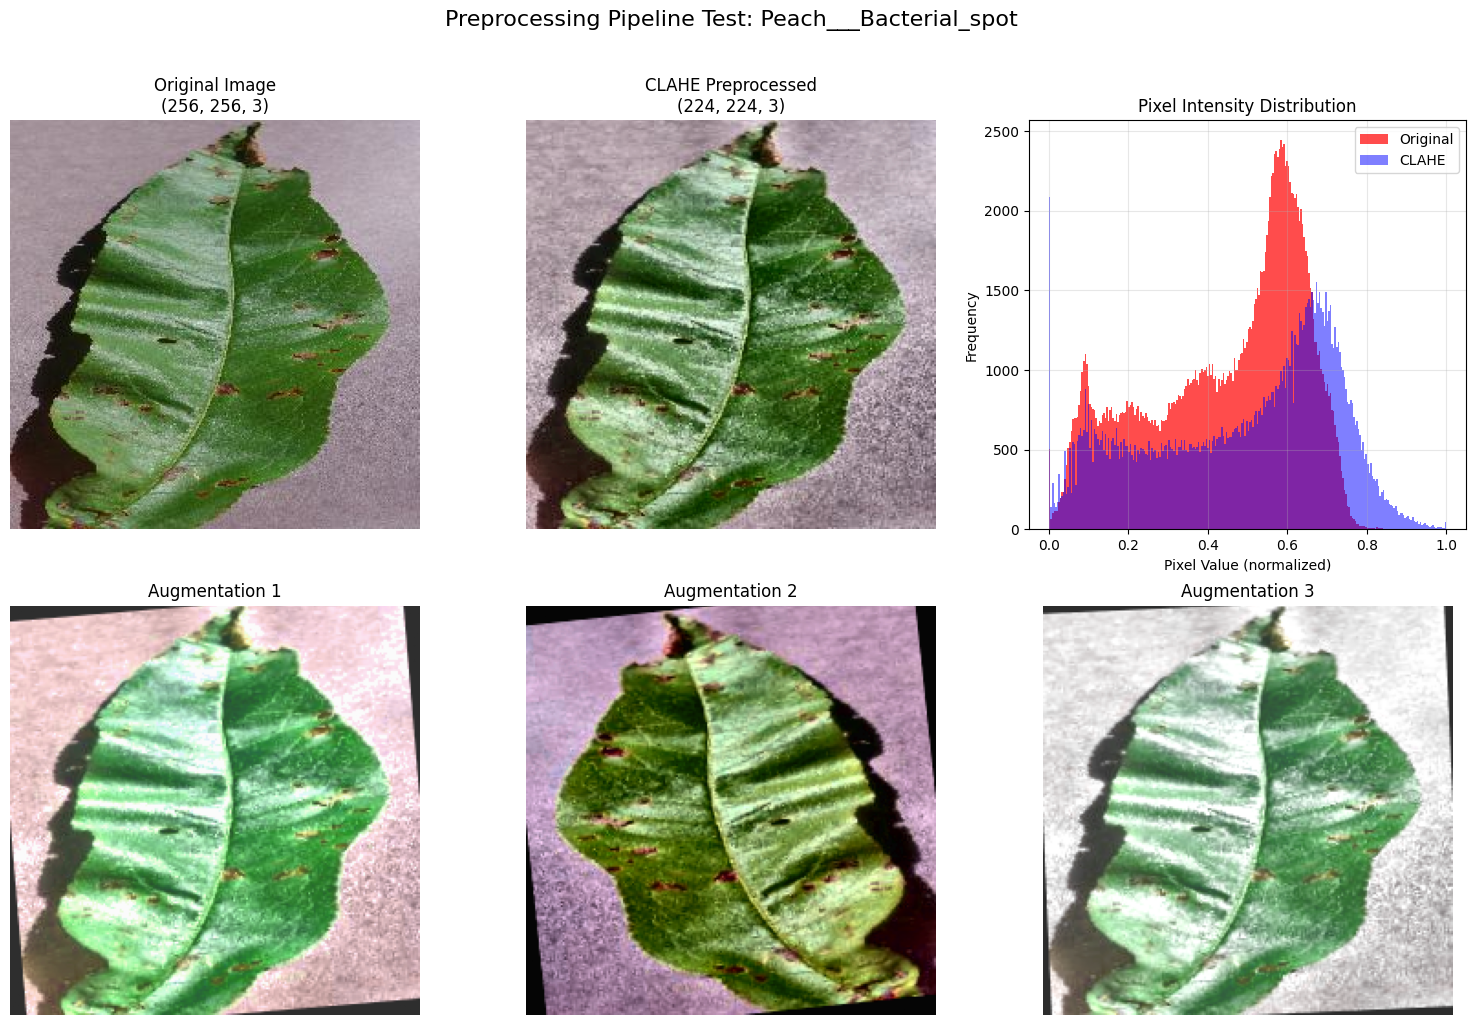

Success: Visualization complete

Image Statistics:
                     Min        Max        Mean       Std       
------------------------------------------------------------
Original (0-255):    0.00       249.00     113.11     49.77     
Original norm:       0.0000     0.9765     0.4436     0.1952    
CLAHE (0-255):       0.00       255.00     123.85     60.07     
CLAHE norm:          0.0000     1.0000     0.4857     0.2356    

Augmentation sample stats:
  Range: [44.00, 255.00] (0-255 scale)
  Normalized range: [0.1725, 1.0000]



In [27]:
# ============================
# STEP 7: Visualize results (FIXED)
# ============================
print("STEP 7: Visualizing results...")

try:
    import matplotlib.pyplot as plt

    # Check if we have the required images
    if 'img' in locals() and 'processed_img' in locals():

        # Prepare images for display (normalize to [0,1] for matplotlib)

        # Original image: uint8 [0,255] -> float32 [0,1]
        original_display = img.astype(np.float32) / 255.0

        # Processed image: from preprocess_numpy_image which returns [0,255]
        processed_array = processed_img.numpy()
        if processed_array.max() > 1.0:
            processed_display = processed_array / 255.0
        else:
            processed_display = processed_array

        # Create figure
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()

        # Original image
        axes[0].imshow(original_display)
        axes[0].set_title(f'Original Image\n{img.shape}', fontsize=12)
        axes[0].axis('off')

        # Preprocessed image (CLAHE)
        axes[1].imshow(processed_display)
        axes[1].set_title(f'CLAHE Preprocessed\n{processed_img.shape}', fontsize=12)
        axes[1].axis('off')

        # Show color histograms - FIXED: Normalize processed image values for histogram comparison
        axes[2].hist(original_display.ravel(), bins=256, color='red', alpha=0.7, label='Original', range=(0,1))

        # For processed image, ensure it's in [0,1] range for histogram
        if processed_array.max() > 1.0:
            processed_hist_data = processed_array / 255.0
        else:
            processed_hist_data = processed_array

        axes[2].hist(processed_hist_data.ravel(), bins=256, color='blue', alpha=0.5, label='CLAHE', range=(0,1))
        axes[2].set_title('Pixel Intensity Distribution', fontsize=12)
        axes[2].set_xlabel('Pixel Value (normalized)')
        axes[2].set_ylabel('Frequency')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        # Test augmentations if available
        if 'test_img' in locals() and 'medium_aug' in locals():
            # Apply 3 different augmentations
            for i in range(3):
                augmented = medium_aug(image=test_img)
                aug_img = augmented['image']

                # Normalize augmented image for display (if needed)
                if aug_img.max() > 1.0:
                    aug_display = aug_img.astype(np.float32) / 255.0
                else:
                    aug_display = aug_img

                axes[3+i].imshow(aug_display)
                axes[3+i].set_title(f'Augmentation {i+1}', fontsize=12)
                axes[3+i].axis('off')
        else:
            # If no augmentations, show info
            for i in range(3):
                axes[3+i].text(0.5, 0.5, 'Augmentation\nExample\nNot Available',
                              horizontalalignment='center', verticalalignment='center',
                              transform=axes[3+i].transAxes, fontsize=12)
                axes[3+i].axis('off')

        plt.suptitle(f'Preprocessing Pipeline Test: {first_class}', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

        print("Success: Visualization complete")

        # Also show statistics
        print("\nImage Statistics:")
        print(f"{'':<20} {'Min':<10} {'Max':<10} {'Mean':<10} {'Std':<10}")
        print(f"{'-'*60}")

        # Original image stats (original range [0,255])
        print(f"{'Original (0-255):':<20} {img.min():<10.2f} {img.max():<10.2f} {img.mean():<10.2f} {img.std():<10.2f}")

        # Original normalized stats
        print(f"{'Original norm:':<20} {original_display.min():<10.4f} {original_display.max():<10.4f} {original_display.mean():<10.4f} {original_display.std():<10.4f}")

        # Processed image stats
        processed_np = processed_img.numpy()
        print(f"{'CLAHE (0-255):':<20} {processed_np.min():<10.2f} {processed_np.max():<10.2f} {processed_np.mean():<10.2f} {processed_np.std():<10.2f}")
        print(f"{'CLAHE norm:':<20} {processed_display.min():<10.4f} {processed_display.max():<10.4f} {processed_display.mean():<10.4f} {processed_display.std():<10.4f}")

        # Augmentation stats if available
        if 'aug_img' in locals():
            print(f"\nAugmentation sample stats:")
            if aug_img.max() > 1.0:
                print(f"  Range: [{aug_img.min():.2f}, {aug_img.max():.2f}] (0-255 scale)")
                print(f"  Normalized range: [{aug_img.min()/255:.4f}, {aug_img.max()/255:.4f}]")
            else:
                print(f"  Range: [{aug_img.min():.4f}, {aug_img.max():.4f}] (normalized)")

    else:
        print("Error: Cannot visualize - required images not available")
        print("Available variables:", [var for var in locals().keys() if not var.startswith('_')])

except Exception as e:
    print(f"Error: Visualization failed: {e}")
    import traceback
    traceback.print_exc()

print()


In [28]:
from tf_datapipeline import get_datasets
import matplotlib.pyplot as plt

print("Testing full data pipeline with batch_size=8...")

# Get datasets
train_ds, val_ds = get_datasets("/content/data/raw/color", batch_size=8, img_size=224)

# Test training dataset
print("\n=== Training Dataset ===")
for images, labels in train_ds.take(1):
    print(f" Batch loaded successfully")
    print(f"  - Images shape: {images.shape}")
    print(f"  - Labels shape: {labels.shape}")
    print(f"  - Pixel range: [{tf.reduce_min(images):.4f}, {tf.reduce_max(images):.4f}]")

    # Visualize the batch
    plt.figure(figsize=(15, 10))
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])
        plt.title(f"Class: {tf.argmax(labels[i]).numpy()}")
        plt.axis('off')
    plt.suptitle("Training Batch - Processed Images")
    plt.tight_layout()
    plt.show()
    break

# Test validation dataset
print("\n=== Validation Dataset ===")
for images, labels in val_ds.take(1):
    print(f"Batch loaded successfully")
    print(f"  - Images shape: {images.shape}")
    print(f"  - Labels shape: {labels.shape}")
    print(f"  - Pixel range: [{tf.reduce_min(images):.4f}, {tf.reduce_max(images):.4f}]")

    # Visualize the batch
    plt.figure(figsize=(15, 10))
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])
        plt.title(f"Class: {tf.argmax(labels[i]).numpy()}")
        plt.axis('off')
    plt.suptitle("Validation Batch - Processed Images")
    plt.tight_layout()
    plt.show()
    break


Output hidden; open in https://colab.research.google.com to view.

In [29]:
print("\n=== Final Pipeline Verification ===")

# Check dataset sizes
print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")

# Check class distribution in one batch
for images, labels in train_ds.take(1):
    class_counts = tf.reduce_sum(labels, axis=0)
    print(f"\nClass distribution in batch (first 5):")
    for i in range(5):
        print(f"  Class {i}: {class_counts[i]:.0f} samples")

    break

print("\nAll tests completed successfully!")
print("\nYour pipeline is now ready for model training. Use:")
print("train_ds, val_ds = get_datasets('/content/data/raw/color', batch_size=32)")
print("model.fit(train_ds, validation_data=val_ds, epochs=10)")



=== Final Pipeline Verification ===
Training batches: 5431
Validation batches: 1358

Class distribution in batch (first 5):
  Class 0: 1 samples
  Class 1: 1 samples
  Class 2: 0 samples
  Class 3: 0 samples
  Class 4: 0 samples

All tests completed successfully!

Your pipeline is now ready for model training. Use:
train_ds, val_ds = get_datasets('/content/data/raw/color', batch_size=32)
model.fit(train_ds, validation_data=val_ds, epochs=10)
